---
title: "3. Acoustics"
subtitle: The physics of sound, rooms, and instruments
---

This week is about *acoustics*, a term everyone knows yet few can define properly. We will go through the physics of sound and then look more closely at instrument acoustics and room acoustics. This is the *physical signal* level of the [four levels of description](#levels-of-description), and it is the only one of the four where the answers do not depend on there being anyone in the room.

```{admonition} Question
:class: question
What is your spontaneous definition of acoustics?
```

## Defining acoustics

Acoustics is the study of sound and its properties. The term comes from the Greek *ἀκουστικός (akoustikos)*, meaning "of or for hearing, ready to hear." According to the American National Standard on acoustical terminology {cite:p}`ANSI_ASA_S1_1_2013`, acoustics has two meanings:

1. The science of sound, encompassing its production, transmission, and effects, both biological and psychological ([acoustics](https://en.wikipedia.org/wiki/Acoustics))
2. The qualities of a room that determine its auditory characteristics (the sub-discipline of [room acoustics](https://en.wikipedia.org/wiki/Room_acoustics)).

We will begin with acoustics broadly and then turn to some of its subdisciplines: room acoustics and instrument acoustics this week and electroacoustics and psychoacoustics in coming weeks. These are only a few of the many subdisciplines of acoustics. Two textbooks anchor most of what follows: the classic student resource is {cite:t}`Rossing2002`, while {cite:t}`HowardAngus2017` is written for music and audio engineering students.

```{image} figures/external/acoustics/03-Lindsay-s-Wheel-of-Acoustics.svg
:alt: Lindsay's Wheel of Acoustics
:width: 100%
```

*Figure: Lindsay's Wheel of Acoustics, illustrating the multidisciplinary nature of acoustics ([source](https://commons.wikimedia.org/wiki/File:Lindsay%27s_Wheel_of_Acoustics.svg)).*

### Why acoustics matters for musicology, music psychology, and music technology

Acoustics gives all three fields their scientific footing for how sound is produced, transmitted, and perceived. In musicology, it helps us analyse the physical properties of instruments and performance spaces, which feeds into historical and cultural studies of music. In music psychology, it underpins research into how we perceive pitch, timbre, loudness, and the spatial qualities of sound, which are the building blocks of musical cognition and emotion. In music technology, it guides the design of audio equipment, recording techniques, and digital sound processing. We will get back to all of these in the coming weeks.

### Cause and effect

At its core, acoustics describes the cause and effect of sound. Seen as a system, it forms a chain from cause to effect:

```mermaid
graph LR
    A[Cause] --> B[Generation]
    B --> C[Propagation]
    C --> D[Reception]
    D --> E[Effect]
```

The generating and receiving mechanisms usually work through *transduction*, the conversion of energy from one form to another (e.g., mechanical to electrical, or vice versa). Sound first propagates through a medium such as air, water, or a solid, and is then transduced again at the point of reception, ready for further processing or perception.

Take a guitarist plucking a string (cause). The string vibrates and generates sound waves (generating mechanism). These waves travel through the air (propagation) and reach the ear, where they are transduced and processed further. We will return to the ear in the [psychoacoustics](psychoacoustics.ipynb) chapter.

The chain can be longer. The sound of a guitar can be picked up by a microphone, which converts the waves into electrical signals (reception/transduction). Those signals are sent to effects pedals and back to a loudspeaker (with amplifier), which turns them back into sound waves (effect/transduction) so the audience can hear the music.

### Sounding objects and sound-producing actions

The "cause" at the start of the chain deserves a closer look. Sound does not appear out of nowhere: someone or something acts on a physical object, and the object responds by vibrating. Acting on an object always produces sound. If the interaction is gentle, the result may be barely audible, but it is there if you listen carefully (or attach a contact microphone).

```mermaid
graph LR
    A[Action] --> B[Object]
    B --> C[Sound]
```

{cite:t}`Jensenius2022` calls this lawful relationship an *action–sound coupling*: the resultant sound follows from the acoustic properties of the sounding object and the (bio)mechanics of the sound-producing action. Given the same object and the same action, the sound will always be the same. A string plucked hard sounds louder than one plucked softly, a large drum sounds deeper than a small one, and nothing changes that. Much of this chapter is about the two halves of this relationship: how objects vibrate and resonate, and how the resulting waves travel through rooms to reach listeners.

Electro-acoustic instruments break this chain. There, the performer's action is captured by a controller, sent to a sound engine, and only turned back into sound by a loudspeaker. The relation between action and sound is then no longer given by physics but is designed: an *action–sound mapping* that can be arbitrary and reprogrammed at will. Pressing a synthesiser key can trigger any sound whatsoever. We return to mappings in the [electroacoustics](electroacoustics.ipynb) chapter, and to the different types of sound-producing actions in [the body](the-body.ipynb) chapter. For now, the point is that in the acoustic world this chapter describes, actions on objects are the core of how sound is created.

## Nature of sound waves

### Vibrations

Vibrations are the oscillatory motions of particles within a medium, and they are what generate sound waves. They can be *periodic* (regular and repeating, as in musical notes) or *aperiodic* (irregular, as in noise). Whether a vibration is periodic or not shapes the resulting sound, including its pitch and timbre. In [psychoacoustics](psychoacoustics.ipynb) we wil treat pitch perception in depth before moving on to understanding how the concept of [harmony and melody](harmony-and-melody.ipynb) relates pitch height and harmonic structure to notation and tonal organisation. Let us start with some basic properties of sound waves.

```{note}
In the following, all the plots will be generated by Python code running inside the Jupyter Notebook that this text is written in. You can at any point in time check the source of the code, and even try yourself locally or in [Colab](https://colab.research.google.com/github/fourMs/sensingsoundandmusic/blob/main/book/acoustics.ipynb). You do not need to understand the details of the code, but as you progress in your learning, it may help to be able to create such plots yourself.
```

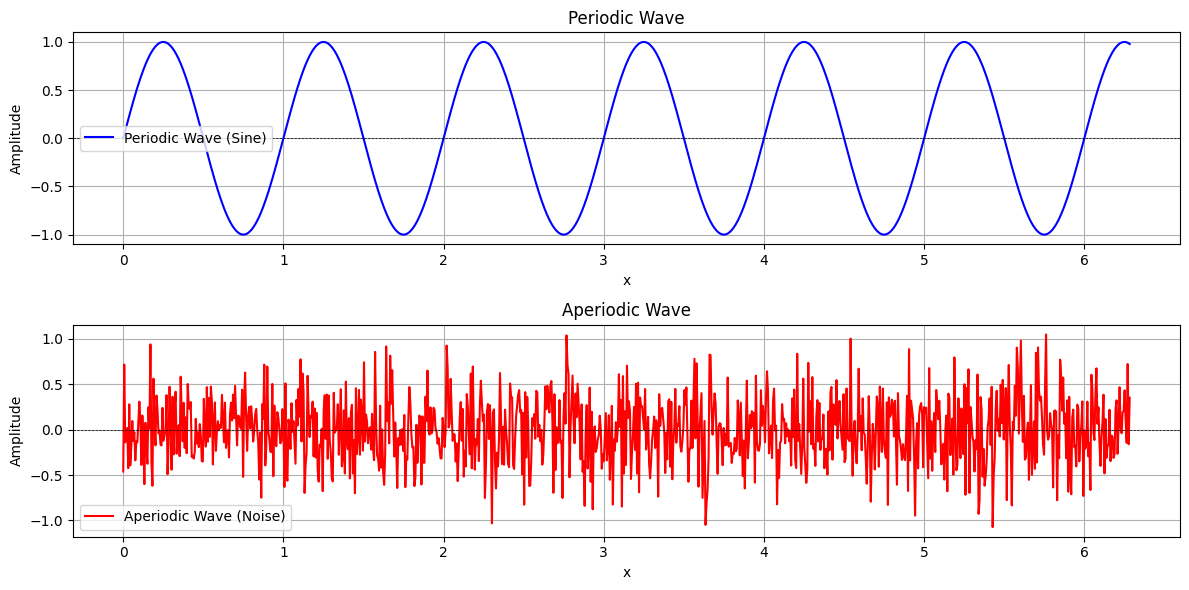

In [1]:
# To make the rest of the code work, we need to load some Python libraries: 
import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import welch

# Define x
x = np.linspace(0, 2 * np.pi, 1000)

# Generate a periodic wave (sine wave)
periodic_wave = np.sin(2 * np.pi * x)

# Generate an aperiodic wave (random noise)
aperiodic_wave = np.random.normal(0, 0.35, len(x))

# Plot the periodic and aperiodic waves
plt.figure(figsize=(12, 6))

# Plot periodic wave
plt.subplot(2, 1, 1)
plt.plot(x, periodic_wave, label='Periodic Wave (Sine)', color='blue')
plt.title('Periodic Wave')
plt.xlabel('x')
plt.ylabel('Amplitude')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()

# Plot aperiodic wave
plt.subplot(2, 1, 2)
plt.plot(x, aperiodic_wave, label='Aperiodic Wave (Noise)', color='red')
plt.title('Aperiodic Wave')
plt.xlabel('x')
plt.ylabel('Amplitude')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

### Longitudinal and transverse waves

Mechanical waves travel through a medium (air, water, or a solid) by making particles vibrate. They are classified by the direction of particle motion relative to the direction the wave travels:

- **Longitudinal waves**: Particles oscillate parallel to the direction the wave travels. Sound waves in air are a common example.
- **Transverse waves**: Particles oscillate perpendicular to the direction of travel. Examples include waves on a string or surface water waves.

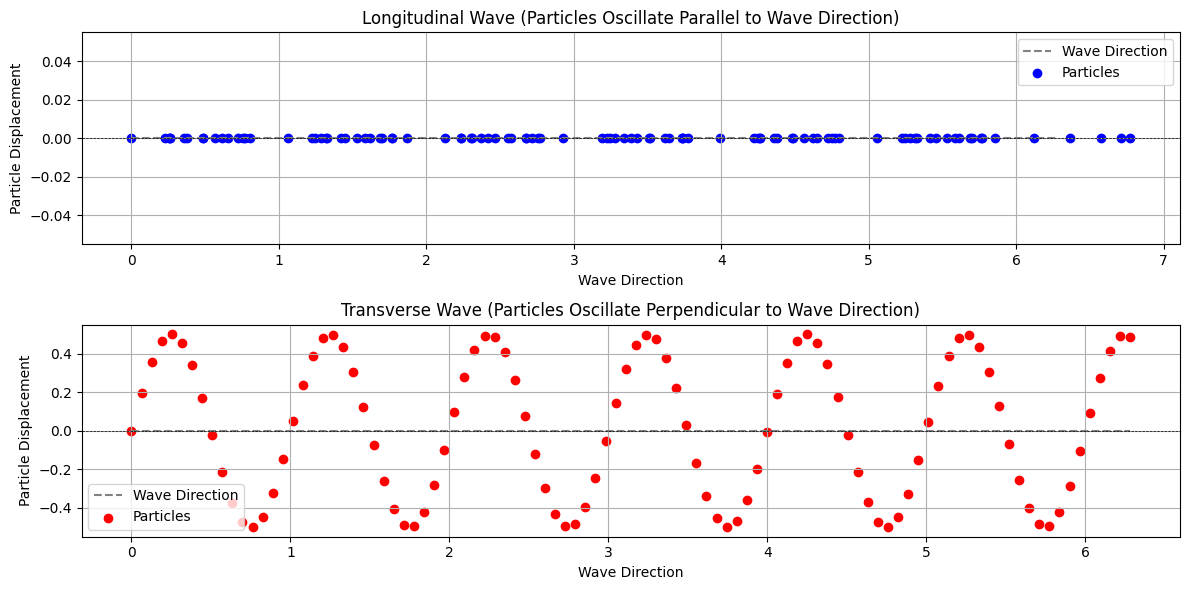

In [2]:
# Define parameters for the waves
x = np.linspace(0, 2 * np.pi, 100)
amplitude = 0.5
frequency = 1

# Generate waveforms
wave = np.sin(2 * np.pi * frequency * x)

# Create particle positions for longitudinal and transverse waves
longitudinal_x = x + amplitude * np.sin(2 * np.pi * frequency * x)
longitudinal_y = np.zeros_like(x)  # No vertical displacement

transverse_x = x  # No horizontal displacement
transverse_y = amplitude * np.sin(2 * np.pi * frequency * x)

# Create the figure
plt.figure(figsize=(12, 6))

# Plot longitudinal wave
plt.subplot(2, 1, 1)
plt.plot(x, np.zeros_like(x), '--', color='gray', label='Wave Direction')
plt.scatter(longitudinal_x, longitudinal_y, color='blue', label='Particles')
plt.title('Longitudinal Wave (Particles Oscillate Parallel to Wave Direction)')
plt.xlabel('Wave Direction')
plt.ylabel('Particle Displacement')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()

# Plot transverse wave
plt.subplot(2, 1, 2)
plt.plot(x, np.zeros_like(x), '--', color='gray', label='Wave Direction')
plt.scatter(transverse_x, transverse_y, color='red', label='Particles')
plt.title('Transverse Wave (Particles Oscillate Perpendicular to Wave Direction)')
plt.xlabel('Wave Direction')
plt.ylabel('Particle Displacement')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

### Frequency

Frequency is the number of complete oscillations, or cycles, a sound wave completes per second, measured in Hertz (Hz). It sets the audible *pitch* of a sound: higher frequencies sound higher, lower frequencies sound lower. It is one of the properties we lean on most when we analyse and describe sound.

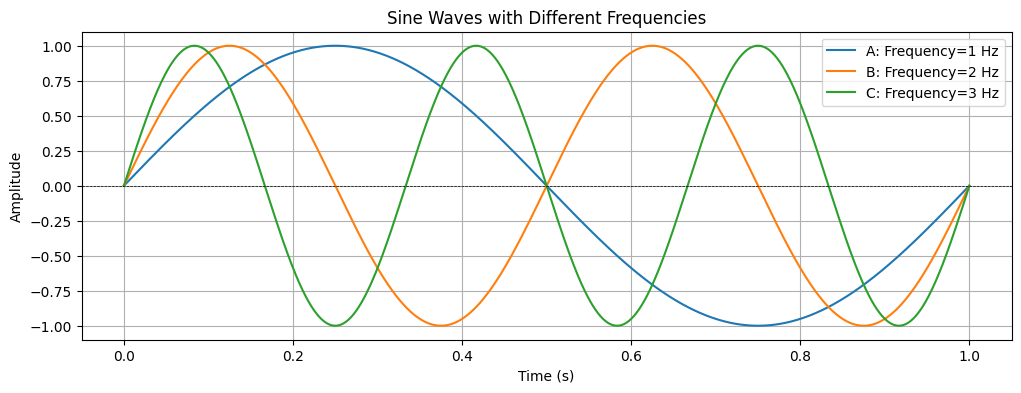

In [3]:
# Define parameters for the sine waves
time = np.linspace(0, 1, 1000)  # Time in seconds (0 to 1 second)
freq1, freq2, freq3 = 1, 2, 3  # Frequencies of the sine waves in Hz
wave1 = np.sin(2 * np.pi * freq1 * time)  # First sine wave
wave2 = np.sin(2 * np.pi * freq2 * time)  # Second sine wave
wave3 = np.sin(2 * np.pi * freq3 * time)  # Third sine wave

# Plot the sine waves
plt.figure(figsize=(12, 4))
plt.plot(time, wave1, label=f'A: Frequency={freq1} Hz')
plt.plot(time, wave2, label=f'B: Frequency={freq2} Hz')
plt.plot(time, wave3, label=f'C: Frequency={freq3} Hz')
plt.title('Sine Waves with Different Frequencies')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()

The frequency of a wave is closely related to its *period*, the time it takes for one complete cycle to occur. The period is measured in seconds (s), while frequency counts the cycles that occur per second, measured in Hertz (Hz).

The frequency of a wave ($f$) is the reciprocal of its period ($T$), and vice versa:

$$f = \frac{1}{T} \qquad T = \frac{1}{f}$$

For example, if a wave has a period of 0.01 seconds, its frequency is f = 1 / 0.01 = 100 Hz. If the frequency is 50 Hz, the period is T = 1 / 50 = 0.02 seconds.

```{admonition} Question
:class: question
What is the period of a sound with a frequency of 440 Hz?
```

### Amplitude

A sound wave's amplitude is what we hear as how "loud" it is. More precisely, amplitude is the maximum displacement of particles in the medium from their rest position as the wave passes. On a graph such as a sine wave, it is the peak value above and below the centre line (zero).

Higher amplitude means more energy in the wave and a louder sound; lower amplitude means a quieter one. Amplitude is typically measured in metres (for displacement), pascals (for pressure), or volts (for electrical signals).

In the plot below, each sine wave has a different amplitude. The peaks and troughs mark the maximum and minimum values, showing how amplitude relates to loudness.

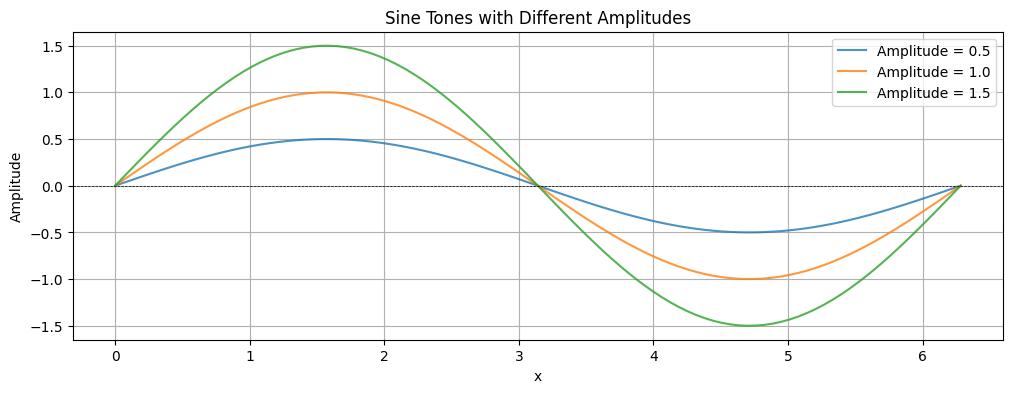

In [4]:
# Define amplitudes for the sine tones
amplitude1 = 0.5
amplitude2 = 1.0
amplitude3 = 1.5

# Generate the sine tones
sine1 = amplitude1 * np.sin(x)
sine2 = amplitude2 * np.sin(x)
sine3 = amplitude3 * np.sin(x)

# Plot the sine tones
plt.figure(figsize=(12, 4))
plt.plot(x, sine1, label='Amplitude = 0.5', alpha=0.8)
plt.plot(x, sine2, label='Amplitude = 1.0', alpha=0.8)
plt.plot(x, sine3, label='Amplitude = 1.5', alpha=0.8)
plt.title('Sine Tones with Different Amplitudes')
plt.xlabel('x')
plt.ylabel('Amplitude')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()

### Sound pressure level (SPL)

[Sound pressure level](https://en.wikipedia.org/wiki/Sound_pressure#Sound_pressure_level) (SPL) measures the pressure variation caused by a sound wave. It is used across acoustics, audio engineering, and environmental noise monitoring to gauge sound levels and check compliance with safety standards. SPL tells us how sound behaves in different environments and how it affects human hearing.

SPL is expressed in [decibels](https://en.wikipedia.org/wiki/Decibel) (dB), a *[logarithmic](https://en.wikipedia.org/wiki/Logarithmic_scale)* unit for the ratio of two values. On a logarithmic scale, each step is a multiplication rather than an addition. An increase of 10 dB corresponds to a tenfold increase in sound intensity, and 20 dB to a hundredfold increase. This lets us represent the enormous range of sound pressures compactly, which suits us well, since human hearing also responds to loudness logarithmically rather than linearly.

The formula for SPL in decibels is:

$$\text{SPL} = 20 \log_{10}\left(\frac{p}{p_0}\right)$$

where $p$ is the measured sound pressure and $p_0$ is the reference sound pressure (typically 20 μPa in air).

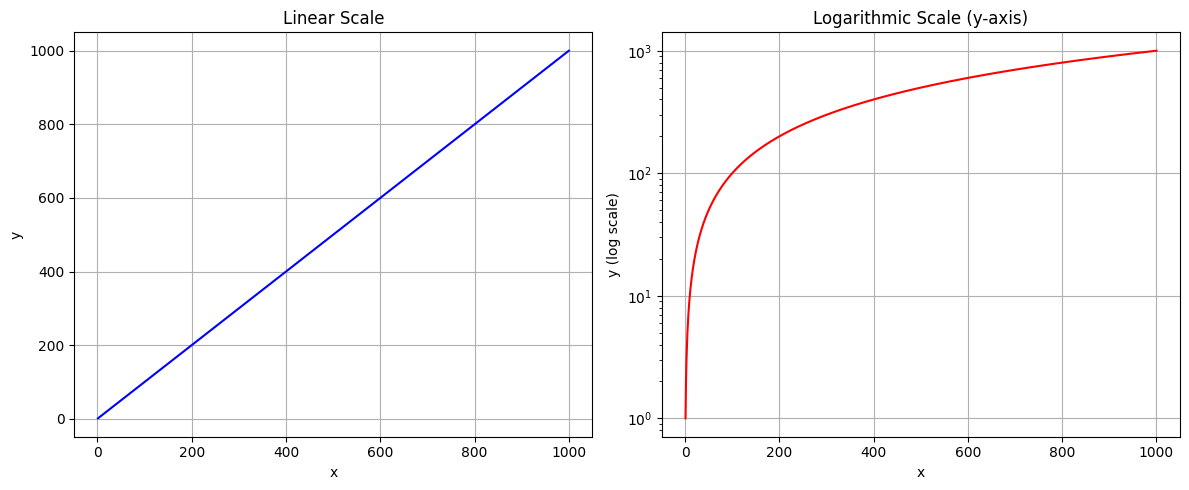

In [5]:
# Plot illustrating regular (linear) vs logarithmic scale

x = np.linspace(1, 1000, 1000)
y = x  # Linear relationship

plt.figure(figsize=(12, 5))

# Linear scale plot
plt.subplot(1, 2, 1)
plt.plot(x, y, color='blue')
plt.title('Linear Scale')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()

# Logarithmic scale plot
plt.subplot(1, 2, 2)
plt.plot(x, y, color='red')
plt.yscale('log')
plt.title('Logarithmic Scale (y-axis)')
plt.xlabel('x')
plt.ylabel('y (log scale)')
plt.grid()

plt.tight_layout()
plt.show()

There are two concepts that are important for understanding how loud something sounds: the 3 dB rule and the inverse-square law. 

The *3 dB rule* says that adding a second identical sound source raises the SPL by about 3 dB, which is double the energy but only a slight gain in perceived loudness. If a single speaker produces 70 dB SPL at a given point, a second identical speaker playing the same signal at the same place brings it to roughly 73 dB. The sound energy doubles, giving the 3 dB increase, but the loudness we hear is only a little greater, not doubled. In the same way, two 60 dB sources combine to about 63 dB. Adding a third 60 dB source brings the total to about 64.8 dB, since three times the energy corresponds to $10\log_{10}(3) \approx 4.8$ dB. A fourth source gives about 66 dB: four times the energy is two doublings, so the level rises by $2 \times 3 = 6$ dB. Notice that each new source contributes less than the one before; it takes a doubling of the number of sources, from two to four, to add the same 3 dB as going from one to two.

You also need the *inverse-square law*: when the distance from a sound source doubles, the sound pressure drops to one-quarter, a 6 dB reduction in SPL. This is why sounds fall away so quickly as you move away from the source.

```{image} figures/external/acoustics/04-Inverse_square_law_mk.svg
:alt: Inverse Square Law
:width: 100%
```

*Figure: Illustration of the Inverse-Square Law, showing how sound pressure decreases with distance ([Wikipedia](https://commons.wikimedia.org/wiki/File:Inverse_square_law_mk.svg)).*

Let us consider an example to understand how the 3 dB rule and inverse-square law work together. Imagine a group of people shouting together. If one person at a fixed distance produces a sound level $L_1$, then $N$ equally strong, independent people produce

$$L_{\mathrm{total}} = L_1 + 10\log_{10}(N).$$

In the figure below, we consider one person shouting at 90 dB. Two people, each shouting at 90 dB, would produce a sound pressure level of 93 dB. If you have a football stadium with 50,000 people, all shouting at 90 dB, they would add up 137 dB. That is only in theory, though. We also need to take into account that these people are all spread around the stadium. Imagine instead that you are standing in the middle of the stadium, with approximately 50 metres to everyone. Then, one person shouting at 90 dB in one of the seats would be heard as 56 dB, two at 59 dB, and 50,000 as 103 dB. That is still very loud, but not as dangerous to the ear.

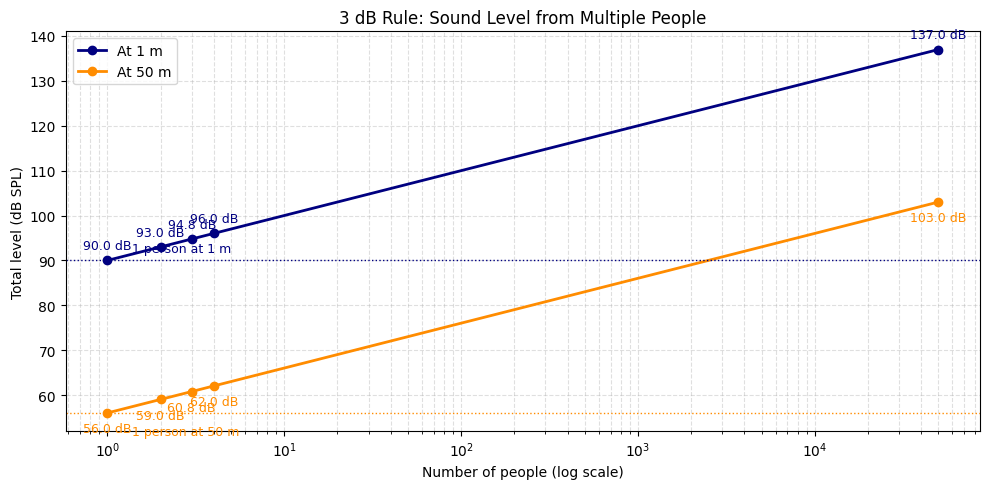

The graph shows the 3 dB rule with and without distance loss.


In [6]:
# 3 dB rule example: one shouter, two shouters, and a full stadium
import numpy as np
import matplotlib.pyplot as plt

L1_1m = 90.0  # dB SPL at 1 m for one strong shout (example value)
r = 50.0  # average distance to listener/mic in meters
L1_at_r = L1_1m - 20 * np.log10(r)

N_values = np.array([1, 2, 3, 4, 50000])
L_total_values = L1_1m + 10 * np.log10(N_values)
L_realistic_values = L1_at_r + 10 * np.log10(N_values)

plt.figure(figsize=(10, 5))
plt.semilogx(N_values, L_total_values, marker='o', linewidth=2, color='navy', label='At 1 m')
plt.semilogx(N_values, L_realistic_values, marker='o', linewidth=2, color='darkorange', label=f'At {r:.0f} m')
plt.title('3 dB Rule: Sound Level from Multiple People')
plt.xlabel('Number of people (log scale)')
plt.ylabel('Total level (dB SPL)')
plt.grid(True, which='both', linestyle='--', alpha=0.4)

for N, L_total in zip(N_values, L_total_values):
    plt.annotate(
        f'{L_total:.1f} dB',
        (N, L_total),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        fontsize=9,
        color='navy',
    )

for N, L_total in zip(N_values, L_realistic_values):
    plt.annotate(
        f'{L_total:.1f} dB',
        (N, L_total),
        textcoords='offset points',
        xytext=(0, -14),
        ha='center',
        fontsize=9,
        color='darkorange',
    )

plt.axhline(L1_1m, color='navy', linestyle=':', linewidth=1)
plt.axhline(L1_at_r, color='darkorange', linestyle=':', linewidth=1)
plt.annotate(
    '1 person at 1 m',
    (1, L1_1m),
    textcoords='offset points',
    xytext=(18, 6),
    ha='left',
    fontsize=9,
    color='navy',
)
plt.annotate(
    f'1 person at {r:.0f} m',
    (1, L1_at_r),
    textcoords='offset points',
    xytext=(18, -16),
    ha='left',
    fontsize=9,
    color='darkorange',
)

plt.legend()
plt.tight_layout()
plt.show()

print('The graph shows the 3 dB rule with and without distance loss.')

*Figure: The blue curve shows the idealised 3 dB rule at 1 m, while the orange curve includes inverse-square distance loss at an average listening distance of 50 m, showing why the realistic stadium level is much lower.*

### Phase

Phase describes the position of a point within a wave cycle, measured in degrees or radians.

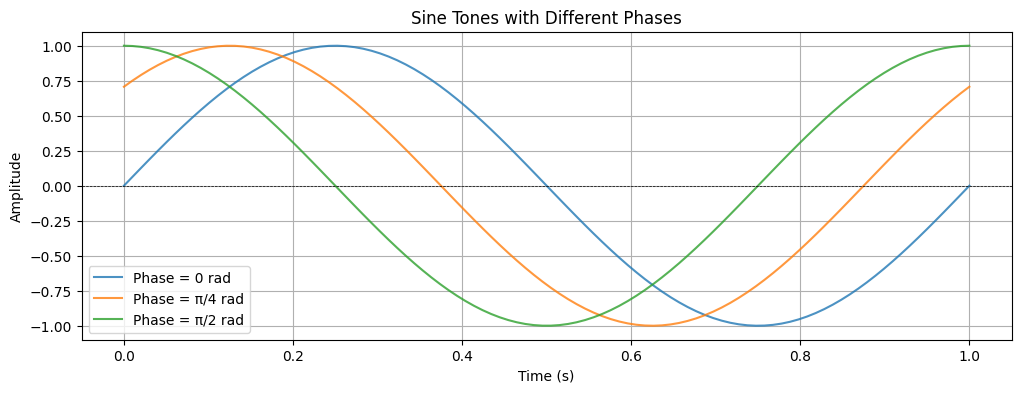

In [7]:
# Define the amplitude and frequency for the sine tones
x = np.linspace(0, 2 * np.pi, 100)
amplitude = 1
frequency = 1  # Frequency in Hz

# Define the phases for the three sine tones
phase1 = 0  # 0 radians
phase2 = np.pi / 4  # 45 degrees in radians
phase3 = np.pi / 2  # 90 degrees in radians

# Convert x to time in seconds
time_in_seconds = x / (2 * np.pi * frequency)

# Generate the sine tones
sine1 = amplitude * np.sin(2 * np.pi * frequency * time_in_seconds + phase1)
sine2 = amplitude * np.sin(2 * np.pi * frequency * time_in_seconds + phase2)
sine3 = amplitude * np.sin(2 * np.pi * frequency * time_in_seconds + phase3)

# Plot the sine tones
plt.figure(figsize=(12, 4))
plt.plot(time_in_seconds, sine1, label='Phase = 0 rad', alpha=0.8)
plt.plot(time_in_seconds, sine2, label='Phase = π/4 rad', alpha=0.8)
plt.plot(time_in_seconds, sine3, label='Phase = π/2 rad', alpha=0.8)
plt.title('Sine Tones with Different Phases')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()

Differences in phase between waves can lead to *constructive interference*, where the waves reinforce each other, or *destructive interference*, where they cancel each other out. This is the principle used in noise-cancelling headphones, which we will get back to next week.

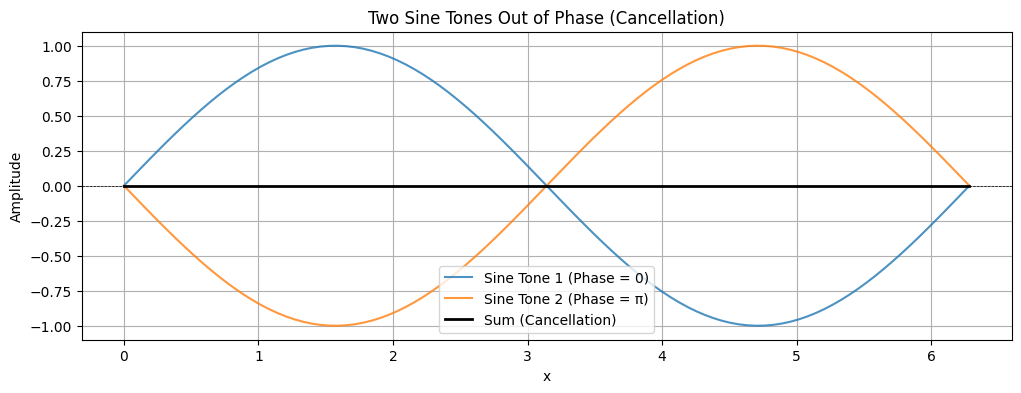

In [8]:
# Define amplitude and frequency for the sine tones
amplitude = 1
frequency = 1  # Frequency in Hz

# Use x from previous cells
# Define two sine tones with opposite phases (0 and pi)
sine1 = amplitude * np.sin(x)
sine2 = amplitude * np.sin(x + np.pi)  # 180 degrees out of phase

# Sum of the two sine tones
sum_wave = sine1 + sine2

# Plot the two sine tones and their sum
plt.figure(figsize=(12, 4))
plt.plot(x, sine1, label='Sine Tone 1 (Phase = 0)', alpha=0.8)
plt.plot(x, sine2, label='Sine Tone 2 (Phase = π)', alpha=0.8)
plt.plot(x, sum_wave, label='Sum (Cancellation)', color='black', linewidth=2)
plt.title('Two Sine Tones Out of Phase (Cancellation)')
plt.xlabel('x')
plt.ylabel('Amplitude')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()

```{exercise}
:label: Phase in production

Open the [phase cancellation](https://fourms.github.io/sensingsoundandmusic/apps/phase-cancellation/) app. Start with two identical tones and shift the phase of one while watching the sum: find the offset where the tones reinforce each other and the offset where they cancel. Then switch to the music loop and raise the level of the inverted copy until the music disappears. Finally, add a few milliseconds of delay to the inverted copy: why do you get a strange colouration instead of silence?
```

### Beating waves

When two sound waves of slightly different frequencies are played together, they interfere with each other. This interference causes the amplitude of the combined wave to fluctuate up and down in a regular pattern, called a *beat*. The *[beat frequency](https://en.wikipedia.org/wiki/Beat_(acoustics))* is equal to the difference between the two original frequencies.

$$f_{\mathrm{beat}} = |f_1 - f_2|$$

For example, two tones with frequencies 440 Hz and 441 Hz will cause a beat frequency of 1 Hz. You hear this as the sound getting louder and softer at this beat frequency. Similarly, two tones at 440 Hz and 442 Hz give a beat frequency of 2 Hz.

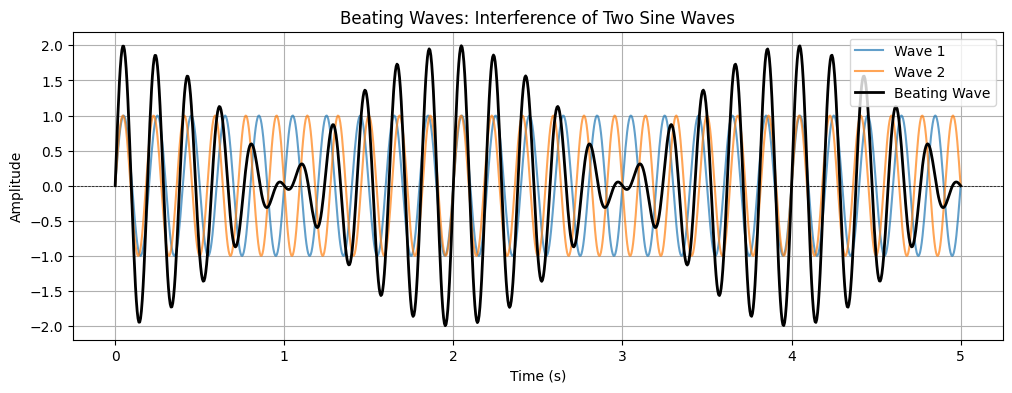

In [9]:
# Define parameters for the two sine waves
frequency1 = 5  # Frequency of the first wave in Hz
frequency2 = 5.5  # Frequency of the second wave in Hz
amplitude = 1  # Amplitude of the waves
time = np.linspace(0, 5, 1000)  # Time array from 0 to 5 seconds

# Generate the two sine waves
wave1 = amplitude * np.sin(2 * np.pi * frequency1 * time)
wave2 = amplitude * np.sin(2 * np.pi * frequency2 * time)

# Generate the resulting wave (superposition)
beating_wave = wave1 + wave2

# Plot the individual waves and the resulting wave
plt.figure(figsize=(12, 4))
plt.plot(time, wave1, label='Wave 1', alpha=0.7)
plt.plot(time, wave2, label='Wave 2', alpha=0.7)
plt.plot(time, beating_wave, label='Beating Wave', color='black', linewidth=2)
plt.title('Beating Waves: Interference of Two Sine Waves')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()

# The same interference at audible frequencies. 440 Hz against 443 Hz beats
# three times a second; its individual cycles are far too fast to plot, which
# is why the figure above uses 5 Hz instead.
from IPython.display import Audio, display

sr = 22050
duration = 3.0
t_audio = np.linspace(0, duration, int(sr * duration), endpoint=False)
f1, f2 = 440.0, 443.0
tone = 0.5 * (np.sin(2 * np.pi * f1 * t_audio) + np.sin(2 * np.pi * f2 * t_audio))
display(Audio(tone, rate=sr))


Beat frequencies are both problematic and helpful. They can cause problems when trying to create a nice-sounding speaker setup. But they are helpful when you want to tune an instrument. Guitarists, for example, often use the beat frequency to tune adjacent strings.

```{exercise}
:label: Beat frequencies

Try to adjust frequencies in the [beating app](https://fourms.github.io/sensingsoundandmusic/beating-demo.html). Set two frequencies a few hertz apart, count the beats per second, and check that the count matches the difference between the two frequencies.
```

### Complex waves

A *complex wave* is a sound wave that consists of multiple frequencies combined together, rather than a single pure tone. Most sounds we hear in everyday life, such as musical notes, speech, or environmental noises, are complex waves. Below is an example of how three different sine tones are added together to create a (slightly) complex tone. 

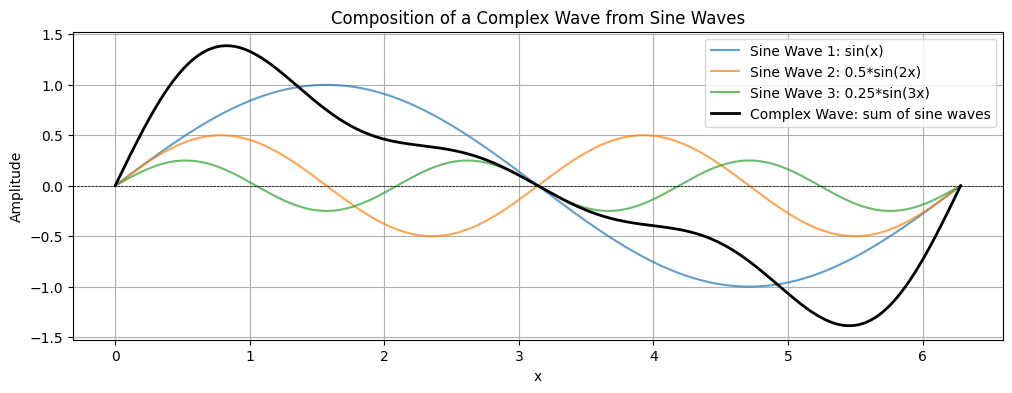

In [10]:
# Define parameters for the sine waves
x = np.linspace(0, 2 * np.pi, 1000)
wave1 = np.sin(x)  # First sine wave
wave2 = 0.5 * np.sin(2 * x)  # Second sine wave with half amplitude and double frequency
wave3 = 0.25 * np.sin(3 * x)  # Third sine wave with quarter amplitude and triple frequency

# Sum of the sine waves (complex wave)
complex_wave = wave1 + wave2 + wave3

# Plot the individual sine waves and the complex wave
plt.figure(figsize=(12, 4))
plt.plot(x, wave1, label='Sine Wave 1: sin(x)', alpha=0.7)
plt.plot(x, wave2, label='Sine Wave 2: 0.5*sin(2x)', alpha=0.7)
plt.plot(x, wave3, label='Sine Wave 3: 0.25*sin(3x)', alpha=0.7)
plt.plot(x, complex_wave, label='Complex Wave: sum of sine waves', color='black', linewidth=2)
plt.title('Composition of a Complex Wave from Sine Waves')
plt.xlabel('x')
plt.ylabel('Amplitude')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid()
plt.show()

When it comes to describing complex tones, there are three closely related terms that describe the sinusoidal components:

- **Partial**: any of the sinusoidal components of a complex tone, including the lowest one. This is the most general term, with no assumption about how the frequencies are related.
- **Harmonic**: a partial whose frequency is a whole-number multiple of the *fundamental frequency* (the lowest partial of a periodic tone). The fundamental is itself the first harmonic, the partial at twice the fundamental is the second harmonic, and so on.
- **Overtone**: any partial above the fundamental. The numbering is therefore shifted by one: the first overtone is the second harmonic.

This is somewhat confusing, because they are often used interchangeably. This table summarises the counting for a harmonic tone with fundamental frequency $f_0$:

| Frequency | Partial no. | Harmonic no. | Overtone no. |
| --- | --- | --- | --- |
| $f_0$ | 1 | 1 | (fundamental) |
| $2f_0$ | 2 | 2 | 1 |
| $3f_0$ | 3 | 3 | 2 |
| $4f_0$ | 4 | 4 | 3 |

In the table, the partial and harmonic numbers are the same. This is the case for most so-called "harmonic" instruments, such as strings, wind instruments, and the voice. For these, the partials are (very nearly) harmonic, which is why their tones have a clear pitch. 

```{exercise}
:label: Complex tones

Try to play with creating different sounds in the [harmonics explorer](https://fourms.github.io/sensingsoundandmusic/apps/harmonics-explorer/) app, which offers eight harmonic sliders over a variable fundamental, together with timbre presets and a missing-fundamental toggle.
```

Other instruments produce *inharmonic* partials that are not whole-number multiples of a common fundamental: bells, gongs, drums, and xylophone bars are typical examples, and their pitch can be ambiguous or absent. Piano strings sit in between, with partials stretched slightly sharp of the harmonic series because of the stiffness of the strings.

```{exercise}
:label: Inharmonic tones

Listen to the difference yourself in the [inharmonicity explorer](https://fourms.github.io/sensingsoundandmusic/apps/inharmonicity-explorer/) app, which lets you strike bell-, gong-, and marimba-like sounds built from partials at non-integer frequency ratios and compare them with a harmonic tone.
```


## Visualising sounds

There are numeours approaches to visualising sounds. Here we will look at some of them.

### Time vs frequency domain

The two most fundamentally different ways of visualising sound can be broken down to:

- **Time domain**: A *waveform display* shows how a signal's amplitude changes over time. This view brings out the shape, duration, and dynamics of the signal.

- **Frequency domain**: A *spectrum* plot or *spectrogram* shows how much of the signal sits in each frequency band. This view is the one to reach for when working with pitch, timbre, and spectral content.

### The Fourier transform

Any complex wave can be broken down into a sum of simpler sinusoids with different frequencies, amplitudes, and phases, a process called *Fourier analysis*. This process is based on the [Fourier transform](https://en.wikipedia.org/wiki/Fourier_transform), a mathematical operation that converts a time-domain signal into its frequency-domain representation. The technique was developed by the French mathematician [Joseph Fourier](https://en.wikipedia.org/wiki/Joseph_Fourier) (1768–1830) and underpins modern signal processing and harmonic analysis.

In practice, the fast Fourier transform (FFT) is an efficient algorithm for computing the Fourier transform, fast enough for real-time analysis of audio in music technology, acoustics, and audio engineering. The transform also runs backwards: an *inverse* Fourier transform turns a spectrum back into a waveform.

```{exercise}
:label: Draw sound

You can try converting a drawing into sound using the [spectral sketch](https://fourms.github.io/sensingsoundandmusic/apps/spectral-sketch/) app, where a drawing on an empty spectrogram is inverse-transformed into sound.
```

### Spectrum and spectrogram

The Fourier transform lets us picture sound in the frequency domain in two main ways:

- **Spectrum**: A plot with frequency on the x-axis and magnitude on the y-axis. It gives a snapshot of the frequency content averaged over the whole signal, that is, which frequencies are present and how strong each one is.

- **Spectrogram**: A representation with time on the x-axis, frequency on the y-axis, and intensity (energy) shown by colour or brightness. It reveals how the frequency content changes over time, so you can see the temporal structure of a sound. Brighter or more intense colours mean stronger energy at a given frequency and time. This makes spectrograms a good fit for musical phrases, speech patterns, and transient events.

To see how the two relate, you can plot the spectrum rotated 90 degrees so its frequency axis lines up with the spectrogram's. Then you can see how the spectrum summarises the whole signal while the spectrogram shows how it develops over time.

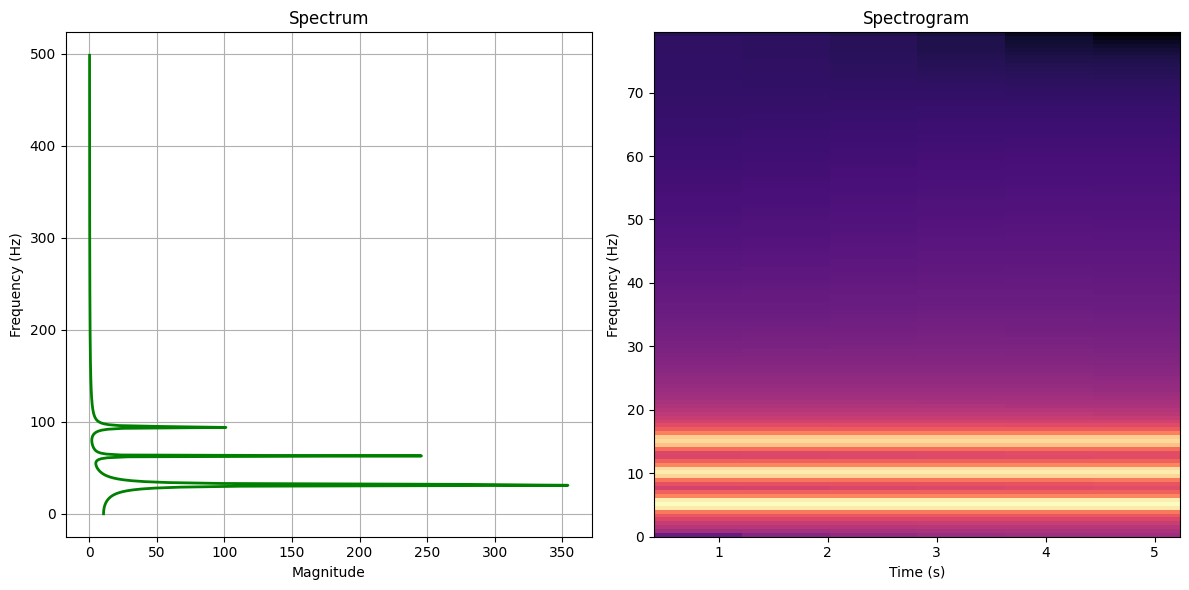

In [12]:
# Define parameters for the complex wave
frequency1 = 5  # Frequency of the first wave in Hz
frequency2 = 10  # Frequency of the second wave in Hz
frequency3 = 15  # Frequency of the third wave in Hz
amplitude1 = 1
amplitude2 = 0.5
amplitude3 = 0.25

# Generate the complex wave as a sum of three sine waves
wave1 = amplitude1 * np.sin(2 * np.pi * frequency1 * x)
wave2 = amplitude2 * np.sin(2 * np.pi * frequency2 * x)
wave3 = amplitude3 * np.sin(2 * np.pi * frequency3 * x)
complex_wave = wave1 + wave2 + wave3

# Compute the Fourier Transform of the complex wave
N = len(complex_wave)
T = (x[1] - x[0]) / (2 * np.pi)
frequencies = fftfreq(N, T)[:N // 2]
fft_values = fft(complex_wave)[:N // 2]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left: Spectrum turned 90 degrees
axes[0].plot(np.abs(fft_values), frequencies, color='green', linewidth=2)
axes[0].set_title('Spectrum')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_xlabel('Magnitude')
axes[0].grid()

# Right: Spectrogram
axes[1].specgram(complex_wave, NFFT=256, Fs=1/(x[1]-x[0]), noverlap=128, cmap='magma')
axes[1].set_title('Spectrogram')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (Hz)')

plt.tight_layout()
plt.show()

```{note}
You may come across the term *sonogram* in the literature. It is essentially a spectrogram of sound signals. For sound and music, they are used interchangeably. However, spectrograms are more general, and can be used to decompose also other types of complex time-based signals.
```


### Windows

When computing a spectrogram, the audio signal is divided into short overlapping segments, and each segment is multiplied by a mathematical function called a [window](https://en.wikipedia.org/wiki/Window_function) before the Fourier transform is applied. The window's *size*, measured as the number of samples (individual digital measurement points) it includes, sets the fundamental trade-off of spectral analysis:

- **Short window (e.g., 256–512 samples):** better *time resolution*, so rapid changes like transients, attacks, or percussive sounds are easier to see. Frequency resolution suffers, so pitch detail is less precise.
- **Long window (e.g., 2048–4096 samples):** better *frequency resolution*, revealing fine pitch detail and harmonics. Time resolution suffers, so fast events blur.

No single setting is right for every sound. Percussive or speech-like signals call for shorter windows, while sustained musical tones benefit from longer ones. The figure below shows the same test signal, steady tones plus a few short clicks, analysed with three window sizes.

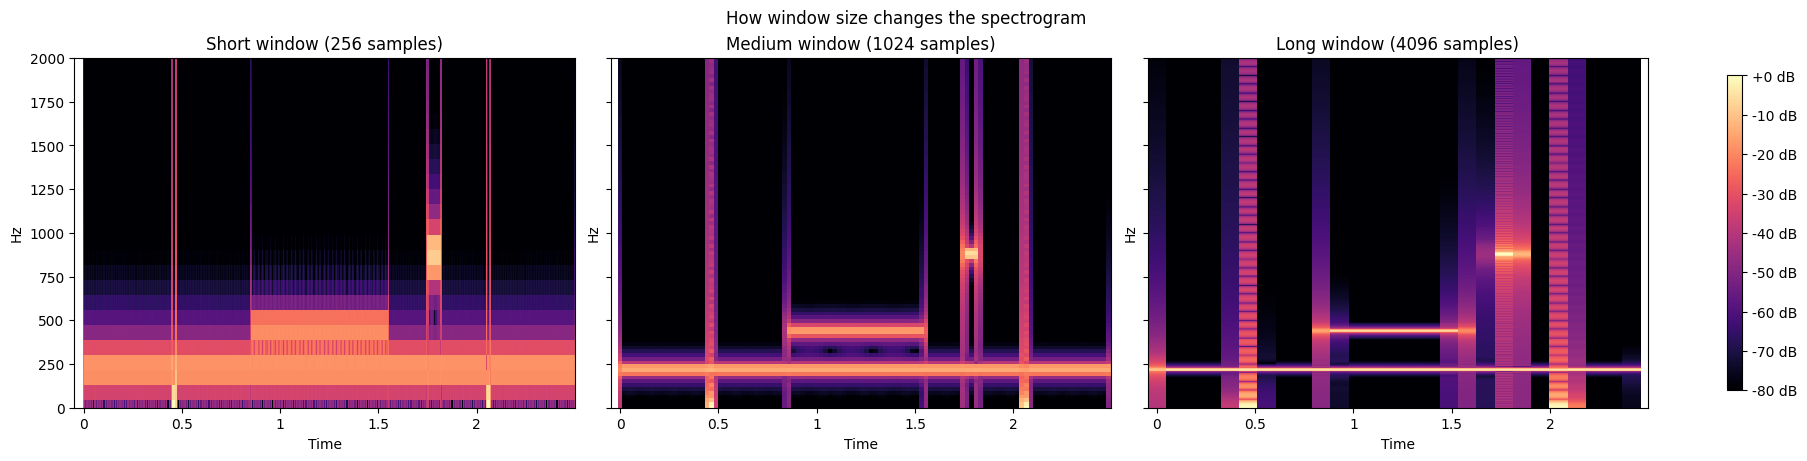

In [13]:
# Compare short, medium, and long analysis windows
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

sr = 22050
duration = 2.5
t = np.linspace(0, duration, int(sr * duration), endpoint=False)

# A simple test signal with steady tones and a few short transients
y = 0.25 * np.sin(2 * np.pi * 220 * t)
y += np.where((t >= 0.85) & (t < 1.55), 0.20 * np.sin(2 * np.pi * 440 * t), 0.0)
y += np.where((t >= 1.75) & (t < 1.82), 0.70 * np.sin(2 * np.pi * 880 * t), 0.0)
y += np.where((t >= 0.45) & (t < 0.47), 0.9, 0.0)
y += np.where((t >= 2.05) & (t < 2.07), -0.9, 0.0)
y = y / np.max(np.abs(y))

window_settings = [
    ('Short window', 256, 128),
    ('Medium window', 1024, 512),
    ('Long window', 4096, 2048),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharex=True, sharey=True, constrained_layout=True)

for ax, (label, n_fft, hop_length) in zip(axes, window_settings):
    D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window='hann')
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='hz', cmap='magma', ax=ax)
    ax.set_title(f'{label} ({n_fft} samples)')
    ax.set_ylim(0, 2000)

fig.suptitle('How window size changes the spectrogram')
fig.colorbar(img, ax=axes.ravel().tolist(), format='%+2.0f dB', shrink=0.9)
plt.show()

```{exercise}
:label: Window explorer

To explore the trade-off yourself, open the [Window explorer](https://fourms.github.io/sensingsoundandmusic/apps/window-explorer/) app, which analyses clicks, closely spaced tones, and a chirp with any window size you choose.
```

The window's *shape* matters less than its size, but it is not arbitrary either. In music and audio analysis the *Hann* window is the usual default, because it performs well across the board; you will meet it as the standard setting in [Sonic Visualiser](https://sonicvisualiser.org/), [Audacity](https://www.audacityteam.org/), and other audio software.

:::{note} Going deeper: window types and overlap
:class: dropdown
Common window types include:

- **Hanning (Hann) window:** Tapers the segment smoothly to zero at the edges, reducing spectral leakage. Widely used for audio analysis.
- **Hamming window:** Similar to Hann but with slightly different tapering, giving a good balance between main-lobe width and side-lobe suppression.
- **Blackman window:** Offers even better side-lobe suppression, useful when minimising leakage is critical.
- **Rectangular window:** No tapering (all ones); it can cause heavy spectral leakage and is rarely used in practice.
- **Terhardt window:** Designed by Ernst Terhardt, tailored for psychoacoustic analysis and auditory modelling. It emphasises perceptual aspects of spectral analysis, aiming to reflect how the ear perceives sound, though it is less common in general audio processing.

Successive windows also *overlap*, typically by 50%–75% of their samples. Overlap smooths the transitions between segments and adds temporal detail without needing more samples. A common choice is 50% overlap (with a 1024-sample window, the next window starts 512 samples later). Speech or transient-rich signals tend to call for shorter windows with moderate overlap, while sustained musical tones or harmonic analysis benefit from longer windows with higher overlap.
:::

Finally, it is also worth considering whether one uses *linear* or *logarithmic* scales in the spectrum or spectrogram. On a linear frequency axis, the frequencies are evenly spaced (e.g., 100 Hz, 200 Hz, 300 Hz). This is handy for technical work, but it compresses the low frequencies and stretches out the high ones, hiding bass and mid-range detail. A logarithmic scale spaces frequencies proportionally instead (octaves: 100 Hz, 200 Hz, 400 Hz, 800 Hz). This matches human hearing and musical pitch perception, so the structure across the whole spectrum is easier to read.

The intensity (colour) scale in a spectrogram can likewise be linear or logarithmic. A logarithmic scale compresses the dynamic range so that both loud and quiet sounds stay visible, which is the standard for audio spectrograms.

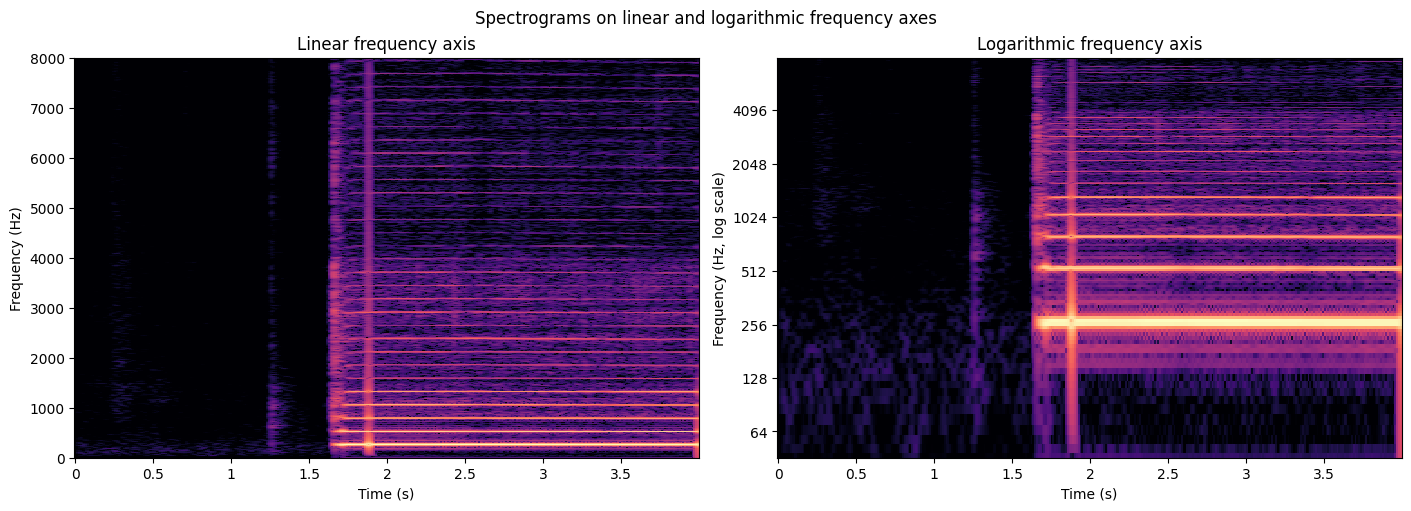

In [14]:
# Compare spectrograms with linear and logarithmic frequency axes
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

y, sr = librosa.load('audio/SoundAction122-Saxophone_tone.wav', sr=22050, mono=True, duration=4.0)
n_fft = 2048
hop_length = 256

D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window='hann')
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='hz', cmap='magma', ax=axes[0])
axes[0].set_title('Linear frequency axis')
axes[0].set_ylim(0, 8000)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Frequency (Hz)')

librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='log', cmap='magma', ax=axes[1])
axes[1].set_title('Logarithmic frequency axis')
axes[1].set_ylim(32, 8000)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (Hz, log scale)')

fig.suptitle('Spectrograms on linear and logarithmic frequency axes')
plt.show()

```{exercise}
:label: Make spectrograms in Sonic Visualiser

Download and install [Sonic Visualiser](https://www.sonicvisualiser.org/), a free tool for visualising and analysing audio files. Open an audio file (such as a recording or sample) and experiment with creating spectrograms:

- Load your audio file into Sonic Visualiser.
- Add a new spectrogram layer (choose "Layer" → "Add Spectrogram").
- Adjust the spectrogram settings (window size, colour map, etc.) to explore how they affect the visualisation.
- Try zooming in and out to examine different time and frequency regions.

How does the spectrogram help you understand the frequency content and changes over time in your audio? Compare the visual patterns for different sounds (speech, music, noise).
```

## Noise

In signal processing, *noise* is defined relative to a *signal*: the signal is the part of a sound or measurement you are interested in, and the noise is everything else. The two form a duality, captured in the *signal-to-noise ratio* (SNR), and what counts as noise depends entirely on what counts as signal. The traffic rumble on a field recording is noise to be filtered away in one project and the very object of study in another.

Acoustically, noise usually refers to random or unpredictable fluctuation in sound, without a clear pitch. In acoustics and audio engineering, the different types of noise are distinguished by their frequency content and how energy is spread across the spectrum. Common types include:

- **White noise**: Contains all frequencies at equal intensity, giving a "hissing" sound like static from a radio or TV. It is often used for sound masking and audio testing thanks to its even frequency distribution.
- **Pink noise**: Has equal energy per octave, so its power decreases as frequency rises. This gives it a deeper sound, like rainfall or wind, and makes it useful for audio calibration and sleep aids.
- **Brownian noise (red noise)**: Emphasises even lower frequencies than pink noise, producing a deep rumble or distant thunder. It is generated by random walk processes and is sometimes called "red noise."
- **Blue noise**: Carries more energy at higher frequencies, giving a brighter, sharper sound. Rare in nature, it is used in dithering for digital audio and image processing.
- **Grey noise**: Shaped so that all frequencies are perceived as equally loud, based on psychoacoustic principles. It is used in research and testing to account for the sensitivity of human hearing.

The differences show up most clearly in the *spectrum*, that is, the average energy at each frequency. In the figure below, the curves are aligned at 1 kHz so that their shapes can be compared directly. The slope is what gives each noise its colour: white noise is flat, pink noise falls by 3 dB per octave, brownian noise by 6 dB per octave, and blue noise rises by 3 dB per octave. Grey noise follows the inverse of a hearing sensitivity curve, boosting the regions where the ear is least sensitive. Impulse noise, on the other hand, has a flat spectrum much like white noise; what sets it apart is how its energy is distributed in *time*, not in frequency.

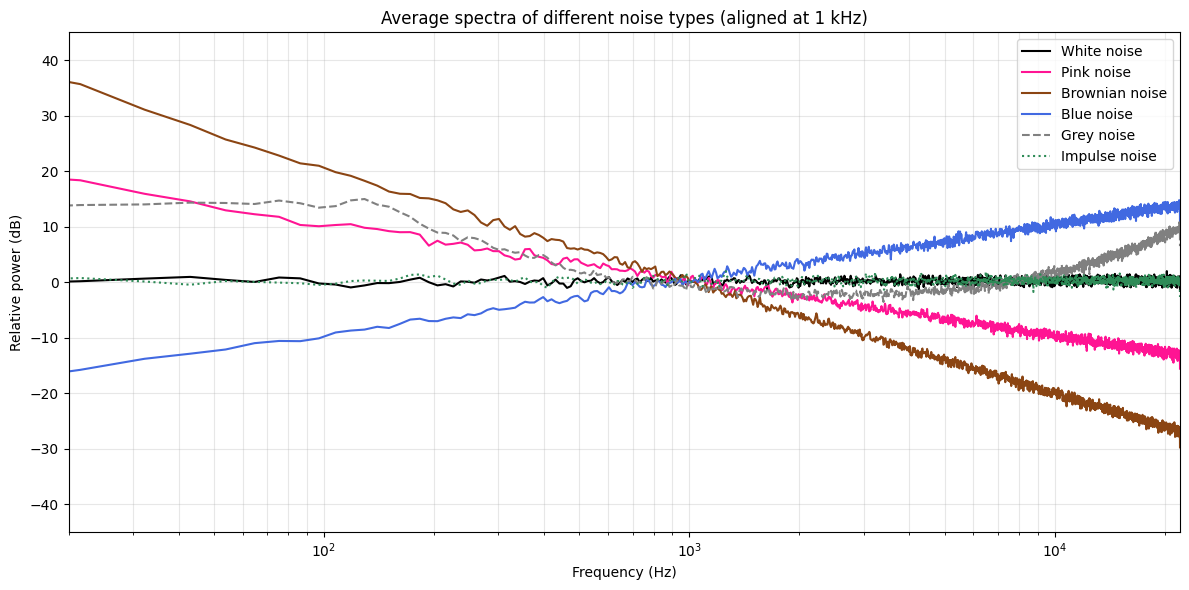

In [15]:
# Define parameters
sampling_rate = 44100  # Hz
duration = 4  # seconds
N = sampling_rate * duration
rng = np.random.default_rng(1)

# Coloured noise is easiest to generate in the frequency domain: start from
# white noise and scale each frequency bin by f**(-beta/2), where beta sets
# how steeply the power falls off with frequency.
def coloured_noise(N, beta, rng):
    spectrum = np.fft.rfft(rng.normal(0, 1, N))
    freqs = np.fft.rfftfreq(N, 1 / sampling_rate)
    scaling = np.ones_like(freqs)
    scaling[1:] = freqs[1:] ** (-beta / 2)
    scaling[0] = 0  # remove the DC component
    return np.fft.irfft(spectrum * scaling, n=N)

white_noise = coloured_noise(N, 0, rng)      # flat spectrum
pink_noise = coloured_noise(N, 1, rng)       # -3 dB per octave
brownian_noise = coloured_noise(N, 2, rng)   # -6 dB per octave
blue_noise = coloured_noise(N, -1, rng)      # +3 dB per octave

# Grey noise is white noise shaped by the inverse of a hearing sensitivity
# curve, here approximated by inverting the standard A-weighting filter
# (with the boost limited so the curve stays readable).
def a_weighting(f):
    f = np.maximum(f, 1e-6)
    num = 12194**2 * f**4
    den = ((f**2 + 20.6**2)
           * np.sqrt((f**2 + 107.7**2) * (f**2 + 737.9**2))
           * (f**2 + 12194**2))
    return num / den

freqs_full = np.fft.rfftfreq(N, 1 / sampling_rate)
grey_gain = a_weighting(1000) / a_weighting(freqs_full)
grey_gain = np.clip(grey_gain, 10**(-15 / 20), 10**(15 / 20))
grey_spectrum = np.fft.rfft(rng.normal(0, 1, N)) * grey_gain
grey_spectrum[0] = 0
grey_noise = np.fft.irfft(grey_spectrum, n=N)

# Impulse noise: random sparse spikes
impulse_noise = np.zeros(N)
impulse_indices = rng.choice(N, size=int(N * 0.001), replace=False)
impulse_noise[impulse_indices] = rng.choice([-1.0, 1.0], size=len(impulse_indices))

noises = [
    ("White", white_noise, "black", "-"),
    ("Pink", pink_noise, "deeppink", "-"),
    ("Brownian", brownian_noise, "saddlebrown", "-"),
    ("Blue", blue_noise, "royalblue", "-"),
    ("Grey", grey_noise, "grey", "--"),
    ("Impulse", impulse_noise, "seagreen", ":"),
]

# Plot the average spectrum of each noise type in the same panel
plt.figure(figsize=(12, 6))
for name, noise, colour, style in noises:
    f, psd = welch(noise, fs=sampling_rate, nperseg=4096)
    psd_db = 10 * np.log10(psd + 1e-20)
    # Align all curves at 1 kHz so the shapes can be compared directly
    ref = np.interp(1000, f, psd_db)
    plt.semilogx(f[1:], psd_db[1:] - ref, label=f'{name} noise',
                 color=colour, linestyle=style)

plt.title('Average spectra of different noise types (aligned at 1 kHz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Relative power (dB)')
plt.xlim(20, sampling_rate / 2)
plt.ylim(-45, 45)
plt.grid(which='both', alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

The noise types above are "constant" in the sense that their characteristics stay the same. There is also *impulse noise*: sudden, short bursts such as clicks, pops, or bangs. Impulse noise is common around machinery, gunshots, and electrical discharges.

Such noise types turn up in audio testing, sound masking, electronic music, and many scientific applications. Knowing the character of each one helps when designing systems for noise reduction, audio analysis, and environmental sound studies.

Note that none of this maps neatly onto how "noise" is used in musical contexts. In everyday speech, noise is unwanted sound, but what is noise to one listener can be music to another: a distorted guitar, a pounding kick drum, or the crackle of vinyl are cherished sonic qualities somewhere. There is even a whole genre of [noise music](https://en.wikipedia.org/wiki/Noise_music), stretching from Luigi Russolo's futurist manifesto *The Art of Noises* (1913) via musique concrète to artists such as [Merzbow](https://en.wikipedia.org/wiki/Merzbow), in which the qualities engineers work to remove are the very material of the music. So keep the two senses apart: in signal processing, noise is defined relative to a signal of interest; in music, "noisiness" is an aesthetic judgement, and no sound is noise by nature.

```{exercise}
:label: Noise maker

Try to make noise yourself in the [noise explorer](https://fourms.github.io/sensingsoundandmusic/apps/noise-explorer/) app, which plays each noise colour as a continuous texture or as a short impulse.
```

## Sound propagation

Sound propagation refers to how sound waves travel through different environments and interact with materials. 

### Medium of propagation

Sound needs a medium, such as air, water, or solids, to travel. The particles in these media vibrate and transmit energy from one place to another. The speed and efficiency of sound propagation depend on the medium’s properties, especially density and elasticity. Generally, sound travels faster in materials that are more elastic and have closely packed particles.

Sound moves fastest in solids (like iron or diamond) because their particles are tightly packed and transmit vibrations efficiently. For example, you can hear a distant train by placing your ear on the rail, as sound travels much faster through metal than air. Here are some examples of the [speed of sound](https://en.wikipedia.org/wiki/Speed_of_sound) in different media:

| Medium   | Speed (m/s) |
|----------|-------------|
| Air      | 343         |
| Helium   | 965         |
| Water    | 1481        |
| Glass    | 4540        |
| Iron     | 5120        |
| Diamond  | 12000       |

Temperature and humidity also affect the speed of sound: warmer or more humid air generally increases it. Altitude matters too, but only indirectly, through the drop in temperature with height. The speed of sound in a gas depends on its temperature and composition, not on pressure or density on their own.

### Reflection, refraction, diffraction, and absorption

Four physics concepts are central to how sound behaves in general, and in rooms and instruments in particular:

- **Reflection**: Sound waves bounce off surfaces, creating echoes and shaping acoustics. In a concert hall, hard walls and ceilings reflect sound, producing reverberation and echoes. Inside a guitar, sound waves reflect off the wooden body, reinforcing certain frequencies and contributing to the instrument's tone.

- **Refraction**: When sound moves between media (e.g., air to water), its speed changes and the wave bends. Temperature gradients in a room can bend sound waves, affecting how sound travels from the stage to the audience. In wind instruments, sound waves refract as they pass through air of varying temperature or humidity inside the instrument, subtly changing pitch and timbre.

- **Diffraction**: Sound waves bend around obstacles and spread out after passing through openings. Sound diffracts around furniture or pillars, so you can hear someone speaking even when they are out of direct line of sight. The sound from a violin's f-holes diffracts, helping project the instrument in all directions.

- **Absorption**: Materials soak up sound energy, reducing its intensity. Carpets, curtains, and acoustic panels absorb sound, cutting echoes and making rooms quieter. The type of wood or material in a drum absorbs some sound energy, affecting the instrument's resonance and sustain.

Together these principles shape how we experience sound everywhere from open fields to concert halls, and they influence both the design and the performance of musical instruments.


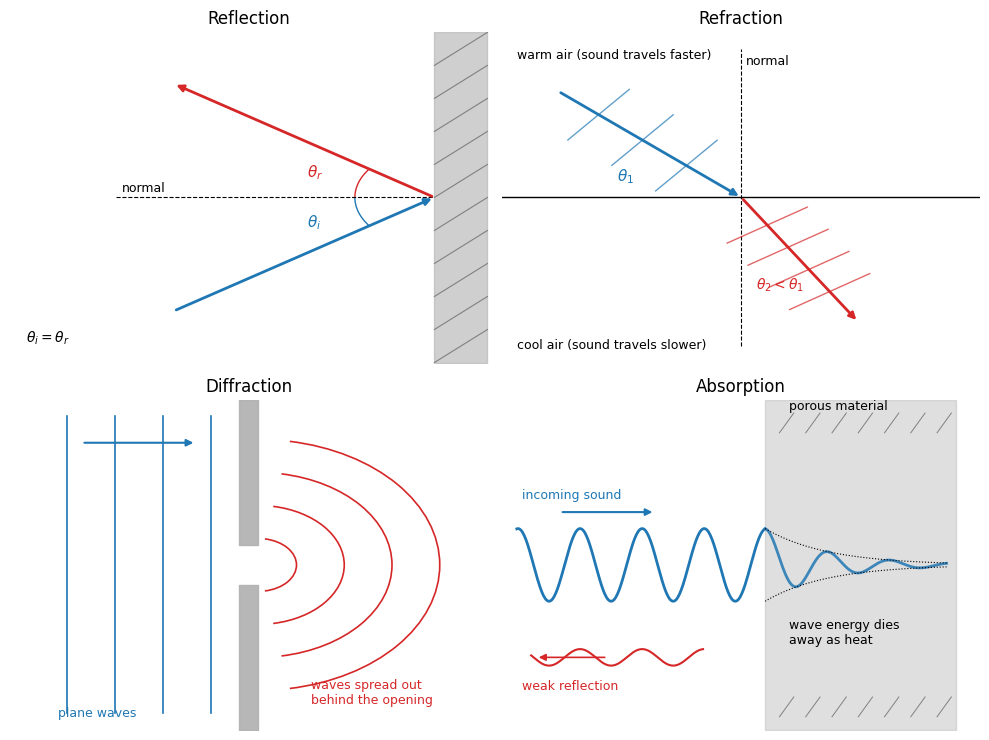

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))
C_IN, C_OUT, C_MAT = "#1f77b4", "#d62728", "#b0b0b0"

# --- A: Reflection -----------------------------------------------------
ax = axes[0, 0]
ax.set_title("Reflection")
# wall on the right
ax.fill_betweenx([0, 10], 8, 9, color=C_MAT, alpha=0.6)
for y in np.arange(0.5, 10, 1):
    ax.plot([8, 9], [y - 0.5, y + 0.5], color="grey", lw=0.8)
P = np.array([8, 5])
ang = np.deg2rad(35)          # angle from the normal (normal = horizontal)
start = P - np.array([6 * np.cos(ang), 6 * np.sin(ang)])
ax.annotate("", xy=P, xytext=start, arrowprops=dict(arrowstyle="-|>", color=C_IN, lw=2))
# reflected: mirror the x-component of direction
end = P + np.array([-6 * np.cos(ang), 6 * np.sin(ang)])
ax.annotate("", xy=end, xytext=P, arrowprops=dict(arrowstyle="-|>", color=C_OUT, lw=2))
ax.plot([2, 8], [5, 5], ls="--", color="k", lw=0.8)   # normal
ax.text(2.1, 5.15, "normal", fontsize=9)
# angle arcs
arc1 = mpatches.Arc(P, 3, 3, angle=0, theta1=180, theta2=180 + 35, color=C_IN)
arc2 = mpatches.Arc(P, 3, 3, angle=0, theta1=145, theta2=180, color=C_OUT)
ax.add_patch(arc1); ax.add_patch(arc2)
ax.text(5.6, 4.1, r"$\theta_i$", color=C_IN, fontsize=11)
ax.text(5.6, 5.6, r"$\theta_r$", color=C_OUT, fontsize=11)
ax.text(0.3, 0.6, r"$\theta_i = \theta_r$", fontsize=10)
ax.set_xlim(0, 9); ax.set_ylim(0, 10); ax.axis("off")

# --- B: Refraction -----------------------------------------------------
ax = axes[0, 1]
ax.set_title("Refraction")
ax.axhline(5, color="k", lw=1)
ax.text(0.3, 9.2, "warm air (sound travels faster)", fontsize=9)
ax.text(0.3, 0.4, "cool air (sound travels slower)", fontsize=9)
P = np.array([5, 5])
th1, th2 = np.deg2rad(50), np.deg2rad(33)   # bends towards the normal in slower medium
start = P + np.array([-5 * np.sin(th1), 5 * np.cos(th1)])
ax.annotate("", xy=P, xytext=start, arrowprops=dict(arrowstyle="-|>", color=C_IN, lw=2))
end = P + np.array([4.5 * np.sin(th2), -4.5 * np.cos(th2)])
ax.annotate("", xy=end, xytext=P, arrowprops=dict(arrowstyle="-|>", color=C_OUT, lw=2))
ax.plot([5, 5], [0.5, 9.5], ls="--", color="k", lw=0.8)
ax.text(5.1, 9.0, "normal", fontsize=9)
# wavefront ticks perpendicular to rays: wider spacing above, narrower below
d1 = np.array([np.sin(th1), -np.cos(th1)])   # travel direction above
p1 = np.array([-np.cos(th1), -np.sin(th1)])  # perpendicular
for t in [1.5, 2.7, 3.9]:
    m = P - d1 * t
    ax.plot([m[0] - p1[0], m[0] + p1[0]], [m[1] - p1[1], m[1] + p1[1]], color=C_IN, lw=1, alpha=0.7)
d2 = np.array([np.sin(th2), -np.cos(th2)])
p2 = np.array([-np.cos(th2), -np.sin(th2)])
for t in [1.0, 1.8, 2.6, 3.4]:
    m = P + d2 * t
    ax.plot([m[0] - p2[0], m[0] + p2[0]], [m[1] - p2[1], m[1] + p2[1]], color=C_OUT, lw=1, alpha=0.7)
ax.text(2.4, 5.5, r"$\theta_1$", color=C_IN, fontsize=11)
ax.text(5.3, 2.2, r"$\theta_2 < \theta_1$", color=C_OUT, fontsize=10)
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis("off")

# --- C: Diffraction ----------------------------------------------------
ax = axes[1, 0]
ax.set_title("Diffraction")
gap_lo, gap_hi = 4.4, 5.6
ax.fill_betweenx([0, gap_lo], 4.8, 5.2, color=C_MAT, alpha=0.9)
ax.fill_betweenx([gap_hi, 10], 4.8, 5.2, color=C_MAT, alpha=0.9)
for x in [1.2, 2.2, 3.2, 4.2]:
    ax.plot([x, x], [0.5, 9.5], color=C_IN, lw=1.2)
ax.annotate("", xy=(3.9, 8.7), xytext=(1.5, 8.7),
            arrowprops=dict(arrowstyle="-|>", color=C_IN, lw=1.5))
centre = (5.2, 5.0)
for r in [0.8, 1.8, 2.8, 3.8]:
    arc = mpatches.Arc(centre, 2 * r, 2 * r, angle=0, theta1=-80, theta2=80, color=C_OUT, lw=1.2)
    ax.add_patch(arc)
ax.text(1.0, 0.4, "plane waves", color=C_IN, fontsize=9)
ax.text(6.3, 0.8, "waves spread out\nbehind the opening", color=C_OUT, fontsize=9)
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis("off")

# --- D: Absorption -----------------------------------------------------
ax = axes[1, 1]
ax.set_title("Absorption")
ax.fill_betweenx([0, 10], 5.5, 9.5, color=C_MAT, alpha=0.4)
for x in np.arange(5.8, 9.5, 0.55):
    ax.plot([x, x + 0.3], [0.4, 1.0], color="grey", lw=0.7)
    ax.plot([x, x + 0.3], [9.0, 9.6], color="grey", lw=0.7)
ax.text(6.0, 9.7, "porous material", fontsize=9)
x1 = np.linspace(0.3, 5.5, 300)
ax.plot(x1, 5 + 1.1 * np.sin(2 * np.pi * x1 / 1.3), color=C_IN, lw=2)
x2 = np.linspace(5.5, 9.3, 300)
env = 1.1 * np.exp(-(x2 - 5.5) / 1.3)
ax.plot(x2, 5 + env * np.sin(2 * np.pi * x2 / 1.3), color=C_IN, lw=2, alpha=0.85)
ax.plot(x2, 5 + env, color="k", lw=0.8, ls=":")
ax.plot(x2, 5 - env, color="k", lw=0.8, ls=":")
x3 = np.linspace(0.6, 4.2, 200)
ax.plot(x3, 2.2 + 0.25 * np.sin(2 * np.pi * x3 / 1.3), color=C_OUT, lw=1.5)
ax.annotate("", xy=(0.7, 2.2), xytext=(2.2, 2.2),
            arrowprops=dict(arrowstyle="-|>", color=C_OUT, lw=1.2))
ax.annotate("", xy=(3.2, 6.6), xytext=(1.2, 6.6),
            arrowprops=dict(arrowstyle="-|>", color=C_IN, lw=1.5))
ax.text(0.4, 7.0, "incoming sound", color=C_IN, fontsize=9)
ax.text(0.4, 1.2, "weak reflection", color=C_OUT, fontsize=9)
ax.text(6.0, 2.6, "wave energy dies\naway as heat", fontsize=9)
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis("off")

fig.tight_layout()
plt.show()


*Four ways sound interacts with surfaces and materials. Reflection: the wave bounces off at the same angle it arrived. Refraction: the wave bends where its speed changes. Diffraction: the wave spreads out behind an opening or obstacle. Absorption: the wave's energy is soaked up by a porous material.*

### The Doppler effect

So far, both source and listener have been standing still. When they move relative to each other, the perceived frequency shifts: the *[Doppler effect](https://en.wikipedia.org/wiki/Doppler_effect)*. A source moving towards you compresses the wavefronts so that more of them arrive per second, raising the pitch; a source moving away stretches them, lowering it. For a source moving at speed $v_s$ and sound travelling at speed $v$, the received frequency is

$$f' = f \, \frac{v}{v \mp v_s},$$

with the minus sign for an approaching source and the plus sign for a receding one. The classic example is an ambulance siren, which drops in pitch the moment the vehicle passes. At 50 km/h the shift is about 4% each way, so the passing siren falls by roughly a semitone and a half in total. At walking speeds the effect is negligible, which is why we never hear it in everyday conversation.

The Doppler effect has also been put to musical use. The [Leslie speaker](https://en.wikipedia.org/wiki/Leslie_speaker), inseparable from the Hammond organ sound, spins its horn so that the sound source constantly moves towards and away from the listener, turning the Doppler shift into a rich vibrato. Sound designers likewise rely on the effect whenever a car, plane, or spell needs to fly convincingly past in a film or game. Like the noise discussion above, it is a reminder that a physical "artefact" in one context can be aesthetic material in another.

## Room acoustics

Room acoustics looks at how the physical characteristics of a space shape sound quality. A room's shape, size, and materials all affect how sound waves behave, and with them the clarity, warmth, and reverberation we hear.

### Room size and shape

A room's dimensions and geometry decide how sound waves reflect, interact, and form standing waves. Irregular shapes and non-parallel surfaces help reduce unwanted echoes and resonances, while rectangular rooms with parallel walls are prone to standing waves, where certain frequencies are reinforced by repeated reflections.

*Standing waves* form when sound waves reflect between parallel surfaces and interfere with themselves, creating regions of constructive and destructive interference. Some frequencies are amplified (peaks) and others diminished (nulls) at particular spots in the room. The effect is strongest at low frequencies and can cause uneven bass response, so some notes sound much louder or softer depending on where you stand. Treating room modes with bass traps and careful placement of speakers and listeners helps minimise these effects.

*Room modes* are the specific frequencies at which standing waves occur, set by the room's dimensions (length, width, height). Each mode is a resonance frequency where sound energy builds up. Modes are categorised as axial (between two parallel surfaces), tangential (between four surfaces), and oblique (between six surfaces). Calculating room modes helps identify problem frequencies and guides acoustic treatment towards a balanced sound.

```{exercise}
:label: Room Modes
Use the [room modes](https://fourms.github.io/sensingsoundandmusic/apps/room-modes/) app on a room you know. Measure its dimensions, look for stacked modes, and use the hear-it buttons to hunt the boom frequencies.
```

Some of you may have come across a particular phenomenon called *flutter echo*: rapid, repetitive echoes that bounce between hard, parallel surfaces such as bare walls or ceilings. As a sound wave reflects back and forth between them, it produces a series of closely spaced echoes that can sound like a "ping-pong" effect or a metallic ringing. Flutter echo is especially noticeable in empty rooms or corridors, and it can degrade speech intelligibility and musical clarity. Acoustic panels or diffusers are often used to break up the parallel surfaces and remove it.

In Oslo, there is an acoustic installation at one of the entrances of the National Theatre train station built around a spectacular flutter echo. Check it out next time you pass by!

```{image} figures/Nationaltheatret-jensenius.jpg
:alt: Nationaltheatret-jensenius.jpg
:width: 100%
```

### Materials

Construction materials do much to shape the acoustic character of a room:

- **Hard surfaces (glass, concrete, tile)**: Reflect sound waves efficiently, raising reverberation and risking echoes. They can make a space sound "live" or "bright," but they can also cause unwanted reflections and clarity problems.
- **Soft materials (carpet, curtains, upholstered furniture, acoustic panels)**: Absorb sound energy, especially at mid and high frequencies, reducing reverberation and echoes. They help create a "dry" or "warm" sound, improving speech intelligibility and musical detail.
- **Porous materials (foam, mineral wool, fibreglass)**: Very effective at absorbing sound, particularly at higher frequencies. Used in acoustic panels and bass traps to control reflections and room modes.
- **Dense materials (brick, stone, thick wood)**: Reflect low-frequency sound and can help contain sound within a space, but they may also contribute to standing waves and bass buildup.
- **Diffusive surfaces (bookshelves, irregular walls, specialised diffusers)**: Scatter sound waves in many directions, breaking up strong reflections and preventing flutter echoes. Diffusion improves clarity and gives a more balanced listening environment.
- **Windows and doors**: Can transmit sound between rooms, affecting isolation and privacy. Double glazing and solid-core doors help reduce sound transmission.

### Acoustic treatment

The shape, size, and construction of a room are hard to change once it is built, so treatment focuses on what can be added or moved. Effective treatment combines absorption, diffusion, and the strategic placement of materials:

- **Absorptive panels**: Usually made from foam, fibreglass, or mineral wool and mounted on walls or ceilings to absorb mid and high frequencies. They reduce reflections, reverberation, and flutter echoes, making speech and music clearer.
- **Bass traps**: Absorbers placed in corners or along walls to target low-frequency energy. They help control room modes and prevent the bass buildup that makes sound uneven and "boomy."
- **Diffusers**: Rather than absorbing, diffusers scatter sound waves in many directions. Often made from wood or plastic with irregular surfaces or patterns, they break up strong reflections and standing waves while keeping a sense of spaciousness and natural ambience.
- **Ceiling clouds**: Suspended panels above listening or performance areas absorb sound from overhead, reducing ceiling reflections and improving clarity.
- **Furniture arrangement**: Placing bookshelves, couches, and other furnishings well can break up reflections, adding both absorption and diffusion, since soft furniture absorbs and irregular surfaces diffuse.
- **Door and window seals**: Seals or heavy curtains on doors and windows improve isolation, keeping unwanted noise from entering or leaving the room.
- **Acoustic curtains and rugs**: Thick curtains and rugs add absorption, especially in rooms with many hard surfaces, taming excess reverberation.

A balanced approach using both absorption and diffusion gives a room that is neither too "dead" nor too "live," supporting accurate sound reproduction and comfortable listening.

```{exercise}
:label: Improving room acoustics

Think about the acoustics of the room you are in. What are the key defining properties of the room? How can you improve it?
```

### Reverberation (T60)

*[Reverberation](https://en.wikipedia.org/wiki/Reverberation)* is one of the most defining acoustic properties of a room. It is the persistence of sound in a space after the source has stopped, caused by reflections from surfaces such as walls, ceilings, and floors.

Acousticians usually quantify reverberation with *T60* (sometimes written RT60): the time it takes for sound to decay by 60 dB after the source stops. The ideal reverberation time depends on what the room is for. Spaces built for speech, such as lecture halls, work best with shorter reverberation times, while concert halls for symphonic music often need longer ones for a fuller sound.

- **Short T60 (0.5–1 s)**: Good for speech and clarity, keeping echoes down and intelligibility up.
- **Moderate T60 (1.5–2 s)**: Suits chamber music, balancing clarity and warmth.
- **Long T60 (2–3 s)**: Favoured for orchestral and choral music, giving a full, immersive sound.

Controlling reverberation is at the heart of designing rooms with the acoustics you want, whether for recording studios, concert halls, or home listening rooms.

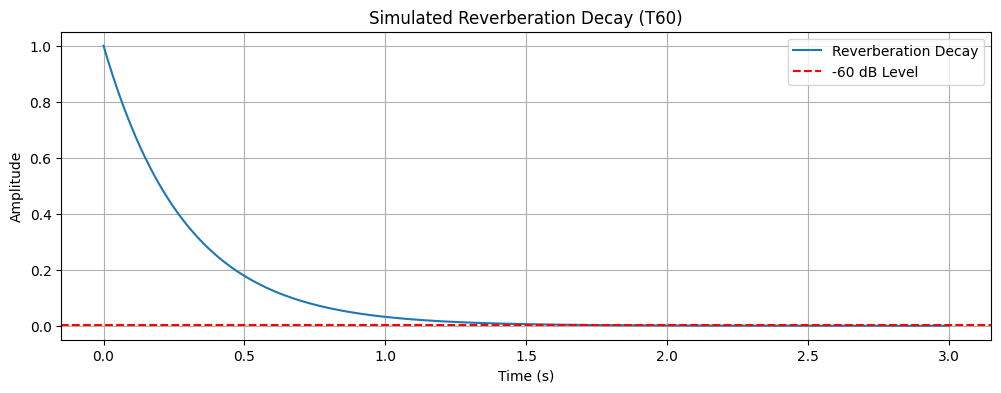

In [16]:
# Simulate a simple exponential decay to illustrate T60 reverberation time
initial_amplitude = 1.0
t = np.linspace(0, 3, 1000)  # 3 seconds duration

# T60 is the time for amplitude to decay by 60 dB (factor of 1/1000)
T60 = 2.0  # seconds (example value)
decay_curve = initial_amplitude * np.exp(-t * np.log(1000) / T60)

plt.figure(figsize=(12, 4))
plt.plot(t, decay_curve, label='Reverberation Decay')
plt.axhline(initial_amplitude / 1000, color='red', linestyle='--', label='-60 dB Level')
plt.title('Simulated Reverberation Decay (T60)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()

### Clarity index and bass ratio

T60 says how *long* sound takes to die away, but not how the energy is distributed while it does. Two further measures fill that in, and you will meet them in any concert-hall report:

- **Clarity (C50, C80)** compares early-arriving energy with late energy. More early energy means crisper attacks and clearer detail; more late energy means a more blended, reverberant sound. C50 (a 50 ms cutoff) is used for speech, C80 (80 ms) for music.
- **Bass ratio (BR)** compares low-frequency reverberation with the mid range. A high BR sounds warm, or boomy; a low one sounds thin.

Neither measure is good or bad in itself. A hall built for late-Romantic orchestral repertoire and one built for spoken theatre should have different values, and both should be read alongside T60.

:::{note} Dig deeper: how clarity and bass ratio are calculated
:class: dropdown
To measure C50 or C80 you first need an impulse response for the room (for example from a sine sweep, a starter pistol, or a balloon pop). You can then calculate the clarity index following the ISO 3382 procedure. A positive Cx means the room has proportionally more early energy, so sounds have crisp attacks and good articulation. A negative Cx means more late energy, so the sound is more reverberant and blended. A very high C80 can make orchestral music sound dry; a very low C80 can make it muddy or indistinct.

Typical target ranges are approximate and depend on what the room is used for. For speech, C50 > 0 dB is generally good, and classrooms often aim for 4–8 dB. For music, C80 varies: large symphonic halls often sit around −2 to +1 dB (favouring richness), while chamber music, amplified pop, or opera that needs more clarity often aims for C80 above 0 up to a few dB. Values above about 3 dB can be very clear but may feel too dry for some orchestral repertoire.

C50 correlates with speech intelligibility indices (such as STI or RASTI); C80 correlates with the perceived clarity of musical detail.

The bass ratio is commonly computed from octave-band reverberation times (e.g., T60 or T20/T30), following Beranek:

- BR ≈ 1 (Beranek's recommendation): balanced low-frequency decay relative to the mids, neither boomy nor thin.
- BR > 1: relatively long low-frequency reverberation, which may be heard as warm or boomy.
- BR < 1: relatively short low-frequency reverberation, which may sound thin or lacking in bass presence.

Concert halls often aim near 1 (slightly above 1 can add warmth), while small rooms and speech spaces may prefer lower values.
:::

```{exercise} Measure your own room
:label: Measure your own room
Reverberation time is one of the few room properties you can measure with equipment you already own.

1. Pick two rooms that sound different, such as a bathroom and a bedroom.
2. In each, start a voice recorder on your phone, stand near the middle, clap once, sharply, and let the room settle before stopping. A single hard clap approximates the impulse the formal method uses.
3. Open each recording in [Sonic Visualiser](https://www.sonicvisualiser.org/) and look at the waveform on a decibel scale. Find the moment of the clap and the moment the decay disappears into the noise floor.
4. You will almost certainly not get a clean 60 dB of decay before the noise floor swallows it, which is exactly why acousticians measure a smaller drop and extrapolate.

Does the room you called "live" have the longer figure?
```

## Instrument acoustics

Room acoustics is a large field, and there are plenty of jobs for people who build and modify rooms in buildings. Far fewer people work on instrument acoustics. The scale is smaller, but most of the same principles apply, now turned to how musical instruments generate, shape, and radiate sound. {cite:t}`Rossing2002` treats each instrument family in detail.

### Principles of instrument acoustics

The main physical principles are the *vibration source* and the instrument's *resonance*. The initial sound comes from vibrating elements such as strings (guitar, violin), air columns (flute, trumpet), membranes (drum), or solid bodies (xylophone). Most instruments then have resonating bodies—soundboards, tubes, shells—that amplify and colour the sound. The shape, size, and material of these bodies set the instrument's timbre and loudness.

The vibration source largely determines the *frequency range* of the instrument. Each instrument has a characteristic range of frequencies it can produce, fixed by its physical dimensions and construction.

```{image} figures/external/acoustics/01-fundamentels_instruments_big.jpg
:alt: Fundamentals of Instrument Acoustics
:width: 100%
```

*Figure: Fundamentals of Instrument Acoustics ([Credit: Sebastian Merchel](http://www.sebastianmerchel.de/)).*

Resonance also shapes *timbre*—the sound "colour"—through the instrument's partials and overtones. Instruments rarely produce pure tones; they generate complex waves with many harmonics, and the relative strength of those harmonics gives each instrument its distinctive sound.

An instrument's *radiation pattern* describes how it projects sound into the surrounding space and depends on its geometry and on playing technique.

:::: {grid} 1 1 2 3
::: {card}
:header: String instruments

When a string is plucked or bowed, it vibrates at its fundamental frequency and produces harmonics. The body of the instrument (such as a guitar or violin) amplifies these vibrations and shapes the sound. The material and construction of the body affect the instrument's tone and projection.
:::

::: {card}
:header: Wind instruments

Wind instruments produce sound by vibrating air columns. The length, shape, and material of the tube set the pitch and timbre. Opening and closing holes changes the effective length of the air column, allowing different notes to be played.
:::

::: {card}
:header: Percussion instruments

Percussion instruments generate sound through striking, shaking, or scraping. The vibration of membranes (drums) or solid bodies (bells, xylophones) creates complex waveforms. The size, tension, and material of the vibrating surface influence the pitch and timbre.
:::
::::


### Organology

Not many people know about it, but there is a (small) academic field devoted to the study of musical instruments: *[organology](https://en.wikipedia.org/wiki/Organology)*. It was developed by (ethno)musicologists and researchers in instrument museums in the late 19th and early 20th century, out of the need to organise large collections of instruments.

The best-known organological system is the [Hornbostel–Sachs System](https://en.wikipedia.org/wiki/Hornbostel%E2%80%93Sachs), which classifies instruments by how they produce sound. The main categories are:

- **Idiophones**: Instruments that produce sound mainly through the vibration of their own material, without strings, membranes, or external air columns. Examples include xylophones, cymbals, and bells.
- **Membranophones**: Instruments that produce sound by vibrating a stretched membrane. Drums are the most common example, where the membrane is struck, rubbed, or otherwise excited.
- **Chordophones**: Instruments that produce sound by vibrating strings stretched between fixed points. This group includes violins, guitars, harps, and pianos.
- **Aerophones**: Instruments that produce sound by vibrating columns of air. Examples are flutes, trumpets, saxophones, and pipe organs.
- **Electrophones**: Instruments that produce sound mainly through electrical means. This includes synthesisers, electric guitars (when amplified), and theremins.

Each category divides further by how the sound is initiated (struck, plucked, bowed, blown, and so on), by the construction of the instrument, and by its acoustic properties. On a lighter note, Disney made an animated film called *Toot Whistle Plunk and Boom* in 1953 that plays with the differences between instruments:

<iframe width="560" height="315" src="https://www.youtube.com/embed/8iVf0pPHvjc?si=Q7N2xX4m8J1x2ZEL" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

(If embedded playback is disabled for this film, watch it [directly on YouTube](https://www.youtube.com/watch?v=8iVf0pPHvjc).)

### The voice

The Hornbostel–Sachs system was developed to categorise instruments in museums and therefore does not include the most common instrument there is: the human voice. The voice is arguably also one of the most complex of all instruments, even though its physical principles can be reduced to two basic parts: a vibration source and a resonator.

The standard description of how the voice works is the [source–filter model](https://en.wikipedia.org/wiki/Source%E2%80%93filter_model) {cite:p}`Sundberg1987`. The source is the pair of [vocal folds](https://en.wikipedia.org/wiki/Vocal_cords) in the larynx. Air pressed up from the lungs sets the folds vibrating, chopping the airflow into a rapid series of puffs. The result is a buzzing tone rich in harmonics, and the rate of vibration sets the pitch, typically around 100–150 vibrations per second in male speech and 200–250 in female speech. The filter is the *vocal tract*, the air-filled tube running from the larynx through the mouth and nose. Like any tube, it has resonances that amplify some harmonics and dampen others, colouring the buzz into a recognisable voice.

The resonance peaks of the vocal tract are called [formants](https://en.wikipedia.org/wiki/Formant). Moving the tongue, lips, and jaw reshapes the tract and shifts the formant frequencies, and the two lowest formants are what distinguish one vowel from another. Sing the same pitch first on "ee" and then on "ah": the vocal folds do the same thing throughout, but the changed filter moves the formants and the vowel changes. This is also why a wah-wah pedal sounds vocal, since it sweeps a resonance in much the way a mouth does.

Singing differs from speech mainly in what the source does. Speech slides quickly through pitches, while singing holds them steady and shapes loudness deliberately. Many singers also add [vibrato](https://en.wikipedia.org/wiki/Vibrato), a regular pitch fluctuation of about five to seven cycles per second that adds warmth and helps a voice blend with or stand out from accompaniment. Because sung vowels are sustained, listeners also get more time to hear the colour of the filter.

Different styles use the instrument in strikingly different ways. Pop and rock singers often rely on [belting](https://en.wikipedia.org/wiki/Belting_(music)), which carries the strong, speech-like setting of the vocal folds much higher in pitch than ordinary speech. Metal screaming and growling recruit structures above the folds to add rough distortion as a deliberate timbral effect. 

Classical singers, performing without microphones, instead rely on the *[singer's formant](https://en.wikipedia.org/wiki/Singer%27s_formant)*: a strong resonance peak around 2,500–3,000 Hz that arises when the third, fourth, and fifth formants are tuned close together, mainly by lowering the larynx and widening the lower throat {cite:p}`Sundberg1987`. The trick works because an orchestra's energy falls off steeply in just that frequency region while the ear is near its most sensitive, so the voice rings through where the accompaniment is weakest. You hear it as the bright "ring" of an operatic voice, and it is what lets a soloist carry over a full orchestra.

```{exercise}
:label: Spectrogram
Try out different singing techniques while watching your own voice in the [live spectrogram](https://fourms.github.io/sensingsoundandmusic/apps/live-spectrogram/) app.
```

## Chapter summary

This chapter linked physical acoustics—waves, spectra, resonance, and rooms—to how instruments and the voice radiate sound and how we visualise and measure signals in time and frequency. It distinguished partials, harmonics, and overtones, surveyed the noise colours while separating the signal processing sense of noise (defined relative to a signal of interest) from aesthetic judgements about noisiness, and followed sound through rooms and past moving sources, where the Doppler effect shifts the pitch. At the root of it all lies the relationship between sound-producing actions and sounding objects: lawful action–sound couplings in the acoustic world, designed action–sound mappings in the electro-acoustic one. The voice fits the same physical framework, with the vocal folds as source and the vocal tract as filter. With that in place, you can start to connect wave physics to what listeners actually hear.

## Questions

1. What distinguishes an action–sound coupling from an action–sound mapping, and why can only the latter be reprogrammed?
2. How do frequency, amplitude, and phase each affect perception and measurement of musical signals?
3. When using spectrograms or spectra for analysis, what trade-offs between time and frequency resolution should you keep in mind?
4. What distinguishes the noise colours from each other, and why can the same sound count as noise in one context and as music in another?
5. What roles do room modes, reflections, and absorption play in perceived timbre and clarity in real spaces?
6. How does the source–filter model explain why two vowels sung on the same pitch sound different?


:::{seealso} Further reading
- **Howard & Angus, *Acoustics and Psychoacoustics* (Focal Press)** — acoustics pitched for music and audio students. https://doi.org/10.4324/9781315716879
- **Rossing, Moore & Wheeler, *The Science of Sound*** — a classic, accessible acoustics textbook. https://www.pearson.com/en-us/subject-catalog/p/science-of-sound-the/P200000006977/9780805385656
- **Johan Sundberg, *The Science of the Singing Voice* (Northern Illinois University Press)** — the classic account of voice acoustics for musicians.
- **Trevor Cox, *The Sound Book*** — a popular tour of acoustics and everyday sound. https://wwnorton.com/books/The-Sound-Book/
:::